# Gibbs Sampler for Gaussian Spatial Models

This notebook demonstrates the **block-Gibbs sampler** for Gaussian spatial regression models (SAR, SEM, SDM, SDEM) in `bayespecon`. The Gibbs sampler exploits conditional conjugacy to avoid the poor NUTS geometry that spatial Jacobians create, often yielding **10–100× faster** sampling for large datasets.

## When to Use Gibbs vs NUTS

| Criterion | NUTS (default) | Gibbs |
|---|---|---|
| **Model type** | Any (Gaussian, Student-t, NB, Probit, Tobit) | Gaussian only (SAR, SEM, SDM, SDEM) |
| **Posterior geometry** | Handles banana/funnel shapes via adaptation | Avoids banana geometry via conjugacy |
| **Speed** | Slow for large $n$ (gradient through Jacobian) | Fast (direct draws for β, σ²; 1-D slice/MALA for ρ/λ) |
| **Robust models** | ✅ Student-t errors | ❌ Not supported |
| **Non-Gaussian** | ✅ NB, Probit, Tobit | ❌ Not supported |
| **ESS/s** | Low for spatial models | High (conjugate blocks mix well) |
| **Tuning** | 1000+ tuning steps needed | Minimal (adaptive slice width or MALA step size) |

**Rule of thumb**: Use `sampler='gibbs'` for Gaussian spatial models with $n > 100$. Use NUTS (default) for non-Gaussian models or when you need Student-t robustness.

In [1]:
%load_ext autoreload
%autoreload 2

import arviz as az
import geopandas as gpd
import libpysal
import numpy as np

from bayespecon.models import SAR, SDEM, SDM, SEM

## Data: Columbus Crime Dataset

We use the classic Columbus (OH) neighbourhood crime dataset from `libpysal`.

In [2]:
# Load Columbus dataset
gdf = gpd.read_file(libpysal.examples.get_path("columbus.shp"))

# Response: crime rate
y = gdf["CRIME"].values.astype(float)

# Covariates: income + housing value
X = np.column_stack(
    [
        np.ones(len(y)),
        gdf["INC"].values.astype(float),
        gdf["HOVAL"].values.astype(float),
    ]
)

# Spatial weights: queen contiguity
W = libpysal.graph.Graph.build_contiguity(gdf)
W = W.transform("r")  # row-standardise

print(f"n = {len(y)}, k = {X.shape[1]}")

n = 49, k = 3


## SAR Model: Gibbs vs NUTS

The SAR (Spatial Autoregressive) model is:

$$y = \rho W y + X\beta + \varepsilon, \quad \varepsilon \sim N(0, \sigma^2 I)$$

The Gibbs sampler uses a **3-block** strategy:
1. **β | ρ, σ², y** — conjugate normal (direct draw)
2. **σ² | β, ρ, y** — conjugate inverse-gamma (direct draw)
3. **ρ | β, σ², y** — 1-D slice sampling or MALA (non-conjugate, scalar)

Only ρ is non-conjugate, and it's a scalar — making the update trivial.

In [3]:
# --- NUTS (default) ---
model_nuts = SAR(y=y, X=X, W=W)
idata_nuts = model_nuts.fit(
    draws=2000,
    tune=1000,
    chains=4,
    target_accept=0.9,
    random_seed=42,
    idata_kwargs={"log_likelihood": True},
)

# --- Gibbs (numpy path) ---
model_gibbs = SAR(y=y, X=X, W=W)
idata_gibbs = model_gibbs.fit(
    sampler="gibbs",
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
    n_jobs=1,
    idata_kwargs={"log_likelihood": True},
)

print("NUTS posterior means:")
print(f"  rho   = {float(idata_nuts.posterior['rho'].mean()):.4f}")
print(f"  beta  = {idata_nuts.posterior['beta'].mean(dim=['chain', 'draw']).values}")
print(f"  sigma = {float(idata_nuts.posterior['sigma'].mean()):.4f}")
print()
print("Gibbs posterior means:")
print(f"  rho   = {float(idata_gibbs.posterior['rho'].mean()):.4f}")
print(f"  beta  = {idata_gibbs.posterior['beta'].mean(dim=['chain', 'draw']).values}")
print(f"  sigma = {float(idata_gibbs.posterior['sigma'].mean()):.4f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


Output()

Sampling 4 chains for 1000 tune and 2000 draw iterations, 4 x 3,000 draws total took 1s (8979 draws/s)
NUTS posterior means:
  rho   = 0.4039
  beta  = [46.42118008 -1.06744828 -0.26050683]
  sigma = 10.3700

Gibbs posterior means:
  rho   = 0.4088
  beta  = [46.04185059 -1.05988684 -0.25946401]
  sigma = 10.3720


In [4]:
az.summary(idata_nuts)["ess_bulk"]

beta[x0]    3085.0
beta[x1]    3584.0
beta[x2]    4543.0
rho         3524.0
sigma       4664.0
Name: ess_bulk, dtype: float64

In [5]:
az.summary(idata_gibbs)["ess_bulk"]

beta[x0]    8033.0
beta[x1]    7893.0
beta[x2]    7967.0
rho         7789.0
sigma       7109.0
Name: ess_bulk, dtype: float64

## Gibbs Backend Options

The Gibbs sampler supports two execution backends:

| Backend | `gibbs_method` | ρ/λ update | JIT compiled | Requires |
|---|---|---|---|---|
| **NumPy** | `"numpy"` (default) | Adaptive slice sampling | No | NumPy only |
| **JAX** | `"jax"` | MALA (gradient-guided) or RW-MH | Yes (`@eqx.filter_jit`) | JAX + equinox |

### NumPy path (default)

The NumPy path uses adaptive slice sampling for ρ/λ. It's pure Python/NumPy — no JAX dependency. Best for moderate $n$ (up to ~1000). Chains run sequentially by default (`chain_method="sequential"`).

### JAX path

The JAX path compiles the entire 3-block Gibbs step into a single XLA kernel via `@eqx.filter_jit`. It uses MALA (Metropolis-adjusted Langevin algorithm) for ρ/λ by default, which leverages `jax.value_and_grad` on the collapsed log-density for gradient-guided proposals. Best for large $n$ where JIT compilation amortizes over many iterations. Chains run in parallel via `jax.vmap` by default (`chain_method="vectorized"`).

In [6]:
# JAX Gibbs path with MALA (default for JAX)
model_jax = SAR(y=y, X=X, W=W)
idata_jax = model_jax.fit(
    sampler="gibbs",
    gibbs_method="jax",  # JAX JIT backend (defaults to chain_method="vectorized")
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
)

# JAX Gibbs path with RW-MH instead of MALA
model_rw = SAR(y=y, X=X, W=W)
idata_rw = model_rw.fit(
    sampler="gibbs",
    gibbs_method="jax",
    use_mala=False,  # Random-walk Metropolis–Hastings
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
)

print("JAX MALA posterior means:")
print(f"  rho   = {float(idata_jax.posterior['rho'].mean()):.4f}")
print(f"  sigma = {float(idata_jax.posterior['sigma'].mean()):.4f}")
print()
print("JAX RW-MH posterior means:")
print(f"  rho   = {float(idata_rw.posterior['rho'].mean()):.4f}")
print(f"  sigma = {float(idata_rw.posterior['sigma'].mean()):.4f}")

Output()

Output()

Sampling 4 chains for 1000 tune and 2000 draw iterations, 4 x 3,000 draws total took 1s (8516 draws/s)


Sampling 4 chains for 1000 tune and 2000 draw iterations, 4 x 3,000 draws total took 1s (12420 draws/s)
JAX MALA posterior means:
  rho   = 0.4289
  sigma = 10.3457

JAX RW-MH posterior means:
  rho   = 0.4271
  sigma = 10.3501


## Log-Determinant Method Choices

The spatial Jacobian $\log|I - \rho W|$ is the computational bottleneck. `bayespecon` supports several approximation methods:

| Method | `logdet_method` | Precompute | Per-ρ cost | JIT-compatible | Best for |
|---|---|---|---|---|---|
| Eigenvalue | `"eigenvalue"` | O(n³) | O(n) | ✅ | n < 500 |
| Chebyshev | `"chebyshev"` | O(nm) | O(m) | ✅ | n < 5000 |
| Trace MC | `"trace_mc"` | O(m) | O(m) | ✅ | n > 5000 |

The Gibbs sampler automatically uses the same logdet method as the model. For the JAX path, all methods are JIT-compatible.

In [7]:
# Chebyshev logdet with JAX Gibbs
model_cheb = SAR(y=y, X=X, W=W, logdet_method="chebyshev")
idata_cheb = model_cheb.fit(
    sampler="gibbs",
    gibbs_method="jax",
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
)

print(
    f"Chebyshev logdet + JAX Gibbs: rho = {float(idata_cheb.posterior['rho'].mean()):.4f}"
)

Output()

Sampling 4 chains for 1000 tune and 2000 draw iterations, 4 x 3,000 draws total took 1s (8839 draws/s)
Chebyshev logdet + JAX Gibbs: rho = 0.4287


## SEM, SDM, and SDEM Models

The Gibbs sampler works for all four Gaussian spatial model types:

| Model | Spatial parameter | ρ/λ update | Null model for ρ/λ |
|---|---|---|---|
| SAR | ρ (lag) | Collapsed slice/MALA | Integrates out β, σ² |
| SEM | λ (error) | Conditional slice/MALA | Conditional on β, σ² |
| SDM | ρ (lag) | Collapsed slice/MALA | Same as SAR, Z = [X, WX] |
| SDEM | λ (error) | Conditional slice/MALA | Same as SEM, Z = [X, WX] |

In [8]:
# SEM Gibbs
model_sem = SEM(y=y, X=X, W=W)
idata_sem = model_sem.fit(
    sampler="gibbs",
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
    n_jobs=-1,
)
print(
    f"SEM Gibbs: lam = {float(idata_sem.posterior['lam'].mean()):.4f}, "
    f"sigma = {float(idata_sem.posterior['sigma'].mean()):.4f}"
)

# SDM Gibbs
model_sdm = SDM(y=y, X=X, W=W)
idata_sdm = model_sdm.fit(
    sampler="gibbs",
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
    n_jobs=-1,
)
print(
    f"SDM Gibbs: rho = {float(idata_sdm.posterior['rho'].mean()):.4f}, "
    f"beta shape = {idata_sdm.posterior['beta'].shape}"
)

# SDEM Gibbs
model_sdem = SDEM(y=y, X=X, W=W)
idata_sdem = model_sdem.fit(
    sampler="gibbs",
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=42,
    n_jobs=-1,
    chain_method="parallel",
)
print(
    f"SDEM Gibbs: lam = {float(idata_sdem.posterior['lam'].mean()):.4f}, "
    f"beta shape = {idata_sdem.posterior['beta'].shape}"
)

SEM Gibbs: lam = 0.5549, sigma = 10.2747
SDM Gibbs: rho = 0.3977, beta shape = (4, 2000, 5)
SDEM Gibbs: lam = 0.4959, beta shape = (4, 2000, 5)


In [9]:
az.summary(idata_sdm)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[x0],44.148,14.105,17.385,70.106,0.161,0.149,7731.0,6287.0,1.0
beta[x1],-0.944,0.371,-1.655,-0.252,0.004,0.003,7926.0,7415.0,1.0
beta[x2],-0.297,0.100,-0.481,-0.107,0.001,0.001,7980.0,7673.0,1.0
beta[W*x1],-0.466,0.633,-1.637,0.708,0.007,0.005,7812.0,7537.0,1.0
beta[W*x2],0.233,0.200,-0.146,0.604,0.002,0.002,7851.0,7509.0,1.0
rho,0.398,0.169,0.085,0.715,0.002,0.002,7722.0,5637.0,1.0
sigma,10.427,1.188,8.234,12.568,0.015,0.012,6559.0,7337.0,1.0


## InferenceData Compatibility

The Gibbs sampler produces the same `az.InferenceData` output as NUTS, with `posterior`, `log_likelihood`, and `observed_data` groups. This means all ArviZ diagnostics (LOO, WAIC, summary, etc.) work seamlessly.

In [10]:
# ArviZ diagnostics work with Gibbs-produced InferenceData
print("Groups:", idata_gibbs.groups())
print()

# LOO cross-validation
loo = az.loo(idata_gibbs)
print(f"LOO: elpd = {loo.elpd_loo:.2f}, SE = {loo.se:.2f}")
print()

# WAIC
waic = az.waic(idata_gibbs)
print(f"WAIC: elpd = {waic.elpd_waic:.2f}, SE = {waic.se:.2f}")
print()

# Summary
az.summary(idata_gibbs, var_names=["rho", "sigma"])

Groups: ['posterior', 'log_likelihood', 'observed_data']

LOO: elpd = -248.88, SE = 21.93

WAIC: elpd = -221.41, SE = 16.51



/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.409,0.126,0.171,0.640,0.001,0.001,7789.0,5424.0,1.0
sigma,10.372,1.121,8.418,12.533,0.013,0.011,7109.0,7337.0,1.0


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

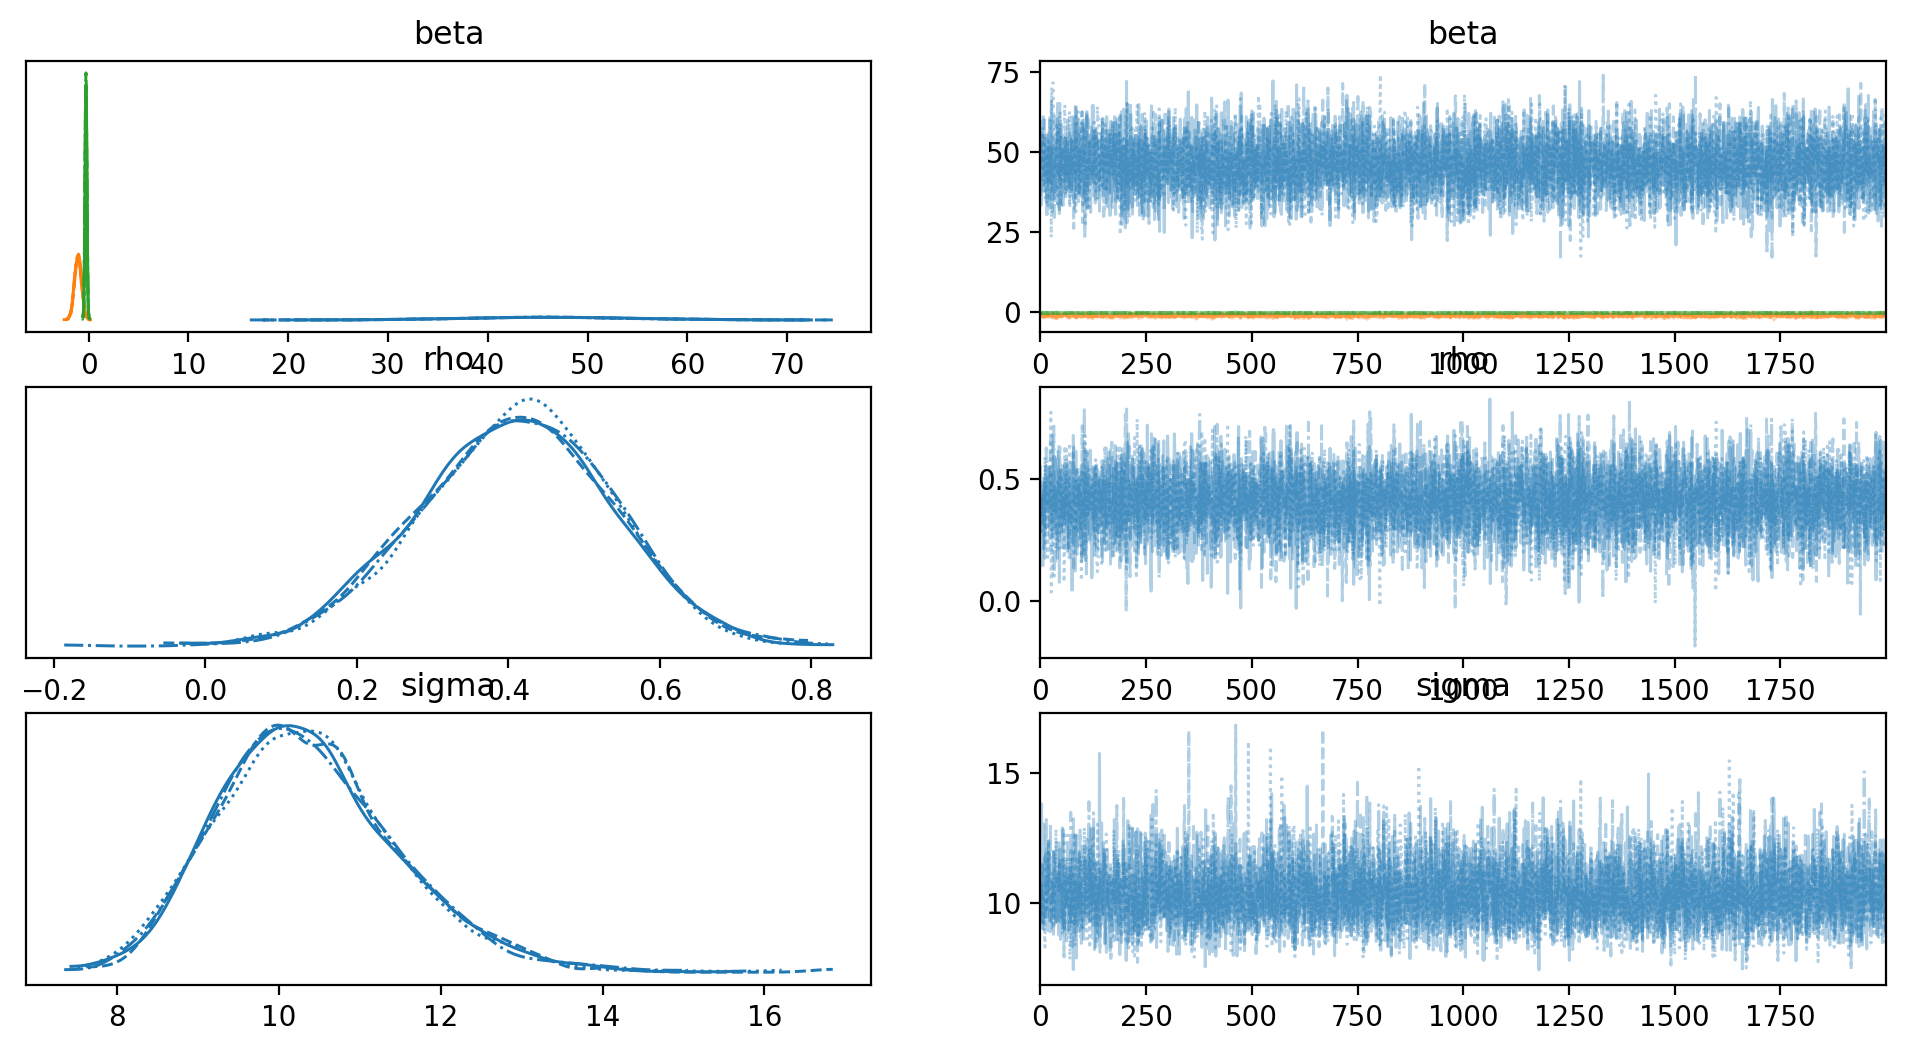

In [11]:
az.plot_trace(idata_gibbs)

## Spatial Diagnostics

The Gibbs-produced `InferenceData` also works with `bayespecon`'s Bayesian LM diagnostics, which test for spatial dependence in the residuals.

In [12]:
# Run spatial diagnostics on the Gibbs-fitted SAR model
report = model_gibbs.spatial_diagnostics()
print(report)

                   statistic      median  df       p_value  ci_lower  \
test                                                                   
LM-Error           60.188363    4.122348   1  8.659740e-15  0.014518   
LM-WX             358.066031  124.063521   2  0.000000e+00  1.435582   
Robust-LM-WX     1662.338877  560.475208   2  0.000000e+00  2.603070   
Robust-LM-Error     0.211501    0.133037   1  6.455932e-01  0.022600   

                    ci_upper  
test                          
LM-Error          532.247645  
LM-WX            2134.938629  
Robust-LM-WX     9927.739730  
Robust-LM-Error     0.861540  


## Summary

The block-Gibbs sampler for Gaussian spatial models in `bayespecon` provides:

1. **Same output format** as NUTS (`az.InferenceData` with `posterior`, `log_likelihood`, `observed_data`)
2. **Two backends**: NumPy (adaptive slice, `n_jobs` controls parallelism) and JAX (MALA or RW-MH, `chain_method` controls parallelism)
3. **All four Gaussian models**: SAR, SEM, SDM, SDEM
4. **Full ArviZ compatibility**: LOO, WAIC, summary, plot
5. **Full diagnostics compatibility**: Bayesian LM tests, spatial diagnostics

```python
# Quick reference
model = SAR(y=y, X=X, W=W)

# NumPy Gibbs (default, n_jobs=-1 runs chains in parallel via joblib)
idata = model.fit(sampler="gibbs", draws=2000, tune=1000, chains=4)

# NumPy Gibbs with sequential chains (for debugging)
idata = model.fit(sampler="gibbs", draws=2000, tune=1000, chains=4, n_jobs=1)

# JAX Gibbs with MALA (chains run in parallel via vmap by default)
idata = model.fit(sampler="gibbs", gibbs_method="jax", draws=2000, tune=1000, chains=4)

# JAX Gibbs with RW-MH
idata = model.fit(sampler="gibbs", gibbs_method="jax", use_mala=False, draws=2000, tune=1000, chains=4)

# Chebyshev logdet + JAX Gibbs
model = SAR(y=y, X=X, W=W, logdet_method="chebyshev")
idata = model.fit(sampler="gibbs", gibbs_method="jax", draws=2000, tune=1000, chains=4)
```